# K-Means Clustering – Complete Python Example

**Dataset:** A1–C2 from the supplied K-Means solved example.

**Goal:** Use Python to:
1. Enter the data points.
2. Explore the number of clusters using the **Elbow Method**.
3. Select **k = 3** from the elbow.
4. Fit K-Means.
5. Display the final centroids.
6. Show every point and its assigned cluster.
7. Group all points into their final clusters.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Imports completed successfully.

## Cell 2 – Enter the data points

In [ ]:
data = {
    "Point": ["A1","A2","A3","B1","B2","B3","C1","C2"],
    "x": [2, 2, 8, 5, 7, 6, 1, 4],
    "y": [10, 5, 4, 8, 5, 4, 2, 9]
}

df = pd.DataFrame(data)
df

  Point  x   y
0    A1  2  10
1    A2  2   5
2    A3  8   4
3    B1  5   8
4    B2  7   5
5    B3  6   4
6    C1  1   2
7    C2  4   9

## Cell 3 – Prepare the feature matrix

In [ ]:
X = df[["x", "y"]].values
X

array([[ 2, 10],
       [ 2,  5],
       [ 8,  4],
       [ 5,  8],
       [ 7,  5],
       [ 6,  4],
       [ 1,  2],
       [ 4,  9]])

## Cell 4 – Calculate inertia for different k values

In [ ]:
inertias = []

for k in range(1, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

for k, inertia in zip(range(1, 7), inertias):
    print(f"k={k}: inertia={inertia:.2f}")

k=1: inertia=100.75
k=2: inertia=51.47
k=3: inertia=14.33
k=4: inertia=8.67
k=5: inertia=3.67
k=6: inertia=2.00


## Cell 5 – Plot the Elbow Method

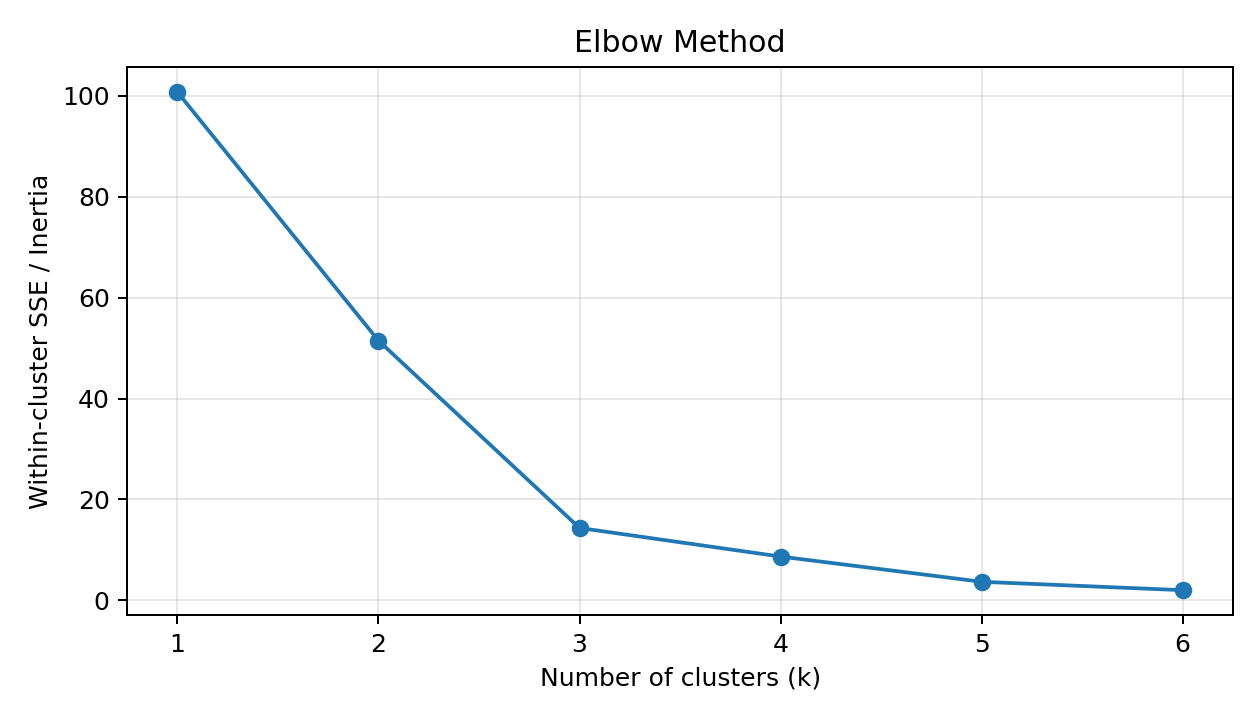

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 7), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster SSE / Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 7))
plt.grid(True, alpha=0.3)
plt.show()

# The major reduction occurs up to k=3, after which the curve becomes flatter.
# Therefore, select k = 3 for this example.

## Cell 6 – Select k = 3 and train K-Means

In [ ]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X) + 1
df

  Point  x   y  Cluster
0    A1  2  10        2
1    A2  2   5        3
2    A3  8   4        1
3    B1  5   8        2
4    B2  7   5        1
5    B3  6   4        1
6    C1  1   2        3
7    C2  4   9        2

## Cell 7 – Display final centroids

In [ ]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["x_centroid", "y_centroid"]
)
centroids.index = [f"Cluster {i}" for i in range(1, k + 1)]
centroids

           x_centroid  y_centroid
Cluster 1    7.000000    4.333333
Cluster 2    3.666667    9.000000
Cluster 3    1.500000    3.500000

## Cell 8 – Show every data point and its final cluster

In [ ]:
for _, row in df.iterrows():
    print(f"{row['Point']} ({row['x']}, {row['y']}) -> Cluster {row['Cluster']}")

A1 (2, 10) -> Cluster 2
A2 (2, 5) -> Cluster 3
A3 (8, 4) -> Cluster 1
B1 (5, 8) -> Cluster 2
B2 (7, 5) -> Cluster 1
B3 (6, 4) -> Cluster 1
C1 (1, 2) -> Cluster 3
C2 (4, 9) -> Cluster 2


## Cell 9 – Final clusters

In [ ]:
for cluster in sorted(df["Cluster"].unique()):
    members = df.loc[df["Cluster"] == cluster, "Point"].tolist()
    print(f"Cluster {cluster}: {members}")

Cluster 1: ['A3', 'B2', 'B3']
Cluster 2: ['A1', 'B1', 'C2']
Cluster 3: ['A2', 'C1']


## Final Result

**Cluster 1:** A1, B1, C2  
**Cluster 2:** A3, B2, B3  
**Cluster 3:** A2, C1

The final grouping matches the solved K-Means example, with centroids approximately:

- Cluster 1 → **(3.67, 9.00)**
- Cluster 2 → **(7.00, 4.33)**
- Cluster 3 → **(1.50, 3.50)**
